In [130]:

import pandas as pd    
import numpy as np       
import matplotlib.pyplot as plt 
import seaborn as sns          
import plotly.express as px   
from datetime import datetime  
import ipaddress            
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
sns.set(style="whitegrid")  
plt.rcParams['figure.figsize'] = (12, 6) 
%matplotlib inline

In [131]:
print("⏳Loading extracted_traffic.csv file....")
df = pd.read_csv('extracted_traffic.csv')
print("✅The file has been uploaded successfully")

⏳Loading extracted_traffic.csv file....
✅The file has been uploaded successfully


In [132]:
print("🔄Time change in progress...")
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df = df.drop(columns=['timestamp'])
df = df.sort_values(by='datetime')
print("🎉The data is ready for display!")
print(f"📊 Number of records (rows): {len(df)}")
print(f"🗓️ First timing: {df['datetime'].min()}")
print(f"🗓️ Latest timing: {df['datetime'].max()}")
display(df.head(10))

🔄Time change in progress...
🎉The data is ready for display!
📊 Number of records (rows): 4060716
🗓️ First timing: 2011-08-18 13:39:35.087798119
🗓️ Latest timing: 2011-08-18 13:53:24.398823023


,src_ip,dst_ip,src_port,dst_port,protocol,packet_len,datetime
0,147.32.84.202,65.54.89.106,1078,80,TCP,54,2011-08-18 13:39:35.087798119
1,88.100.184.137,147.32.85.26,13121,62860,TCP,54,2011-08-18 13:39:35.087914944
2,147.32.85.26,88.100.184.137,62860,13121,TCP,54,2011-08-18 13:39:35.088321924
3,147.32.85.26,88.100.184.137,62860,13121,TCP,54,2011-08-18 13:39:35.088373899
4,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.089900970
5,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.090195894
6,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.090203047
7,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.090245008
8,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.090332985
9,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.090554953


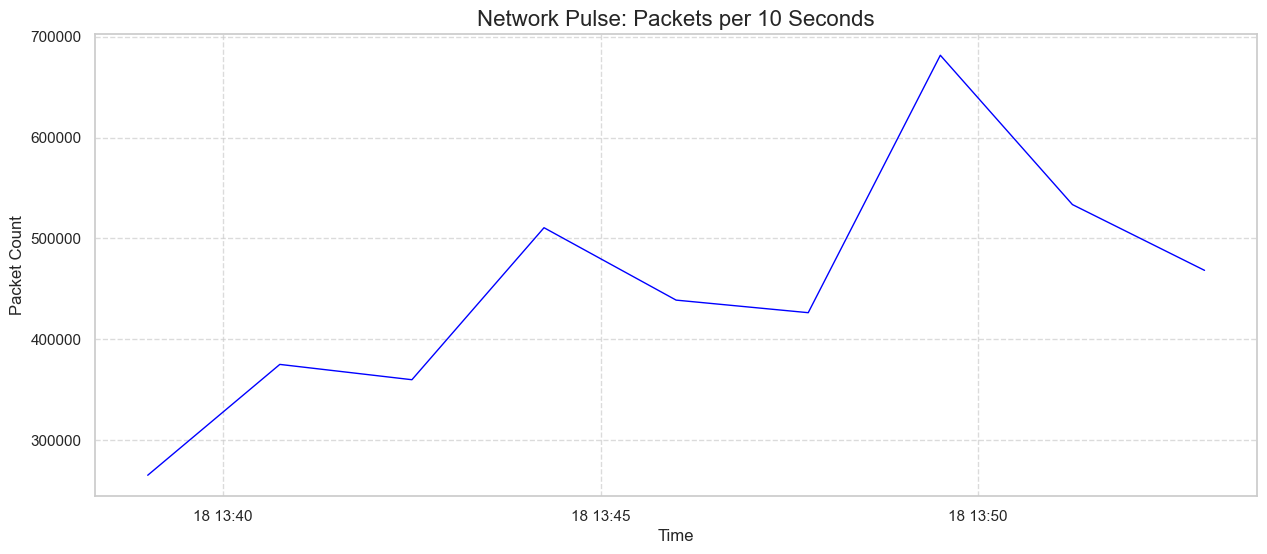

In [133]:
df_time = df.set_index('datetime') 
df_resampled=df_time.resample('105s').size()
plt.figure(figsize=(15, 6))
plt.plot(df_resampled.index, df_resampled.values, color='blue', linewidth=1)
plt.title('Network Pulse: Packets per 10 Seconds', fontsize=16) 
plt.xlabel('Time', fontsize=12)
plt.ylabel('Packet Count', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

⚔️ The protocols used are currently being analyzed... 
📊Analysis results: weapon selection
protocol
TCP     1833058
UDP     1827603
ICMP     400055
Name: count, dtype: int64


c:\Program Files\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128737 (\N{SHIELD}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Program Files\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


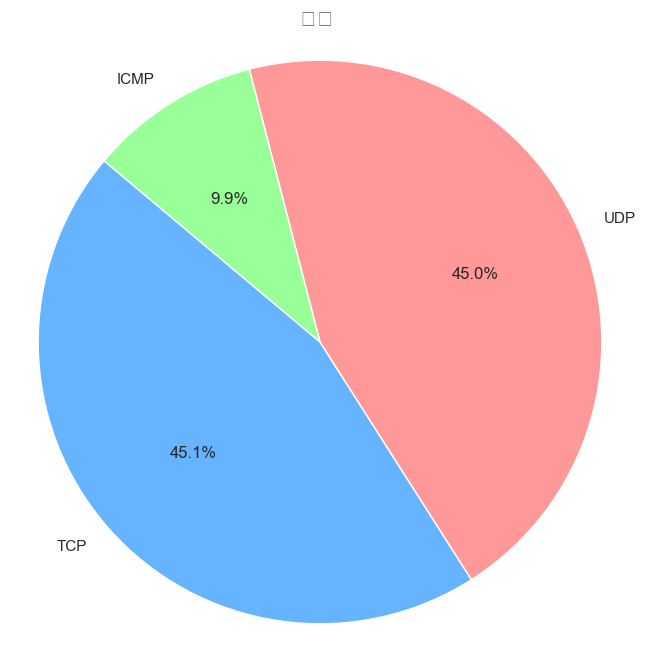

In [134]:
print("⚔️ The protocols used are currently being analyzed... ")
protocol_counts = df['protocol'].value_counts()
print("📊Analysis results: weapon selection")
print(protocol_counts)
plt.figure(figsize=(8, 8))
colors = ['#66b3ff', '#ff9999', '#99ff99', '#ffcc99'] 
plt.pie(protocol_counts, labels=protocol_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=colors)
plt.title('🛡️ ', fontsize=16)
plt.axis('equal') 
plt.show()

In [135]:
print("=" * 50)
print("Forensic report")
print("=" * 50)
start_time = df['datetime'].min()
end_time = df['datetime'].max()
Duration= (end_time - start_time ).total_seconds() /60
print(f" Attack time :")
print(f"Beginning {start_time}" )
print(f"End  {end_time}")
print(f"Duration {Duration:.2f}  minute") 

Forensic report
 Attack time :
Beginning 2011-08-18 13:39:35.087798119
End  2011-08-18 13:53:24.398823023
Duration 13.82  minute


In [136]:
top_protocol = df['protocol'].value_counts().idxmax()
print(f"\n Weapon used : ")
print(f"Controlling protocol : {top_protocol} ")


 Weapon used : 
Controlling protocol : TCP 


In [137]:
top_Victim_ip = df['dst_ip'].value_counts().idxmax()
top_Victim_count = df['dst_ip'].value_counts().idxmax()
print(f"\n Primary target ")
print(f"Victim's address : {top_Victim_ip}")
print(f"Number of attacks : {top_Victim_count}")


 Primary target 
Victim's address : 147.32.84.59
Number of attacks : 147.32.84.59


In [138]:
top_attacker_ip = df['src_ip'].value_counts().idxmax()
print(f"\n  Suspect: ")
print(f"Source Title : {top_attacker_ip}")
print("=" * 50)
print("Ready to Display")
print("=" * 50)


  Suspect: 
Source Title : 147.32.84.59
Ready to Display


🔎(Target Ports)...
Top 10 ports targeted by attackers:
dst_port
43087    924126
0        400107
80       388780
13121    212639
60146    155929
62860    116828
12649    114858
33188    107410
443       84037
10662     62071
Name: count, dtype: int64


C:\Users\aminm\AppData\Local\Temp\ipykernel_13872\262434236.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_ports.values, y=top_ports.index, palette='viridis')
c:\Program Files\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128682 (\N{DOOR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


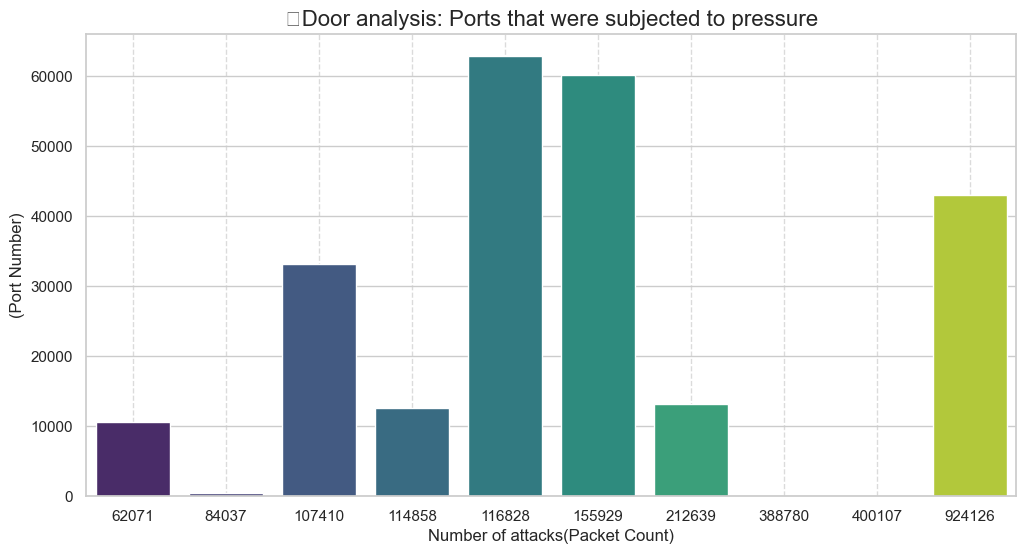

In [139]:
print("🔎(Target Ports)...")
top_ports = df['dst_port'].value_counts().head(10)
print("Top 10 ports targeted by attackers:")
print(top_ports)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_ports.values, y=top_ports.index, palette='viridis')
plt.title('🚪Door analysis: Ports that were subjected to pressure', fontsize=16)
plt.xlabel('Number of attacks(Packet Count)', fontsize=12)
plt.ylabel('(Port Number)', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.show()

In [140]:
print("=" * 60)
print("CYBER SECURITY FORENSIC REPORT")
print("=" * 60)
start_time = df['datetime'].min()
end_time = df['datetime'].max()
duration_sec = (end_time - start_time).total_seconds()
duration_min = duration_sec / 60
print("\n[⏱️] TIMELINE OF ATTACK")
print("-" * 60)
print(f"Start Time   : {start_time}")
print(f"End Time     : {end_time}")
print(f"Total Duration: {duration_min:.2f} minutes ({duration_sec:.2f} seconds)")
top_proto = df['protocol'].value_counts().idxmax()
top_proto_count = df['protocol'].value_counts().max()
print("\n[⚔️] WEAPON ANALYSIS")
print("-" * 60)
print(f"Dominant Protocol: {top_proto}")
print(f"Total Packets    : {top_proto_count}")
top_victim_ip = df['dst_ip'].value_counts().idxmax()
top_victim_count = df['dst_ip'].value_counts().max()
print("\n[🎯] TARGET ANALYSIS")
print("-" * 60)
print(f"Primary Target IP : {top_victim_ip}")
print(f"Packet Hits      : {top_victim_count}")
top_attacker_ip = df['src_ip'].value_counts().idxmax()
top_attacker_count = df['src_ip'].value_counts().max()
print("\n[👺] SUSPECT ANALYSIS")
print("-" * 60)
print(f"Suspect IP  : {top_attacker_ip}")
print(f"Packet Hits : {top_attacker_count}")
# 5. Which Door? (Top Port)
top_port = df['dst_port'].value_counts().idxmax()
top_port_count = df['dst_port'].value_counts().max()
print("\n[🚪] PORT ANALYSIS")
print("-" * 60)
print(f"Targeted Port : {top_port}")
print(f"Hit Count     : {top_port_count}")
print("\n" + "=" * 60)
print("                    END OF REPORT")
print("=" * 60)

CYBER SECURITY FORENSIC REPORT

[⏱️] TIMELINE OF ATTACK
------------------------------------------------------------
Start Time   : 2011-08-18 13:39:35.087798119
End Time     : 2011-08-18 13:53:24.398823023
Total Duration: 13.82 minutes (829.31 seconds)

[⚔️] WEAPON ANALYSIS
------------------------------------------------------------
Dominant Protocol: TCP
Total Packets    : 1833058

[🎯] TARGET ANALYSIS
------------------------------------------------------------
Primary Target IP : 147.32.84.59
Packet Hits      : 1144049

[👺] SUSPECT ANALYSIS
------------------------------------------------------------
Suspect IP  : 147.32.84.59
Packet Hits : 639449

[🚪] PORT ANALYSIS
------------------------------------------------------------
Targeted Port : 43087
Hit Count     : 924126

                    END OF REPORT


In [141]:
display(df)

,src_ip,dst_ip,src_port,dst_port,protocol,packet_len,datetime
0,147.32.84.202,65.54.89.106,1078,80,TCP,54,2011-08-18 13:39:35.087798119
1,88.100.184.137,147.32.85.26,13121,62860,TCP,54,2011-08-18 13:39:35.087914944
2,147.32.85.26,88.100.184.137,62860,13121,TCP,54,2011-08-18 13:39:35.088321924
3,147.32.85.26,88.100.184.137,62860,13121,TCP,54,2011-08-18 13:39:35.088373899
4,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.089900970
...,...,...,...,...,...,...,...
4060711,147.32.84.165,147.32.96.69,0,0,ICMP,66,2011-08-18 13:53:24.398619890
4060712,147.32.84.191,147.32.96.69,0,0,ICMP,66,2011-08-18 13:53:24.398627996
4060713,147.32.84.165,147.32.96.69,0,0,ICMP,66,2011-08-18 13:53:24.398720980
4060714,147.32.84.191,147.32.96.69,0,0,ICMP,66,2011-08-18 13:53:24.398771048


In [142]:
target_column = 'src_ip'
top_n = 10  
print(f"🔢 Analyzing Column: {target_column}")
print("-" * 40)
df_clean = df[df['dst_port'] < 10000]
result = df_clean[target_column].value_counts().head(top_n)
print(f"🏆 Top {top_n} most repeated values:")
print("-" * 40)
print(result)
top_value = result.index[0]
count = result.values[0]
print(f"\n✨ The Winner: '{top_value}' repeated {count} times.")

🔢 Analyzing Column: src_ip
----------------------------------------
🏆 Top 10 most repeated values:
----------------------------------------
src_ip
147.32.84.191     294453
147.32.84.165      98514
147.32.84.59       82333
147.32.84.2        65925
78.128.193.149     55660
147.32.84.94       50584
218.75.208.58      41194
147.32.84.202      29154
65.54.89.106       26521
147.32.85.8        24572
Name: count, dtype: int64

✨ The Winner: '147.32.84.191' repeated 294453 times.


In [143]:
target_column = 'dst_ip'
top_n = 10  
print(f"🔢 Analyzing Column: {target_column}")
print("-" * 40)
df_clean = df[df['dst_port'] < 10000]
result = df_clean[target_column].value_counts().head(top_n)
print(f"🏆 Top {top_n} most repeated values:")
print("-" * 40)
print(result)
top_value = result.index[0]
count = result.values[0]
print(f"\n✨ The Winner: '{top_value}' repeated {count} times.")

🔢 Analyzing Column: dst_ip
----------------------------------------
🏆 Top 10 most repeated values:
----------------------------------------
dst_ip
147.32.96.69     394198
147.32.84.2      104959
218.75.208.58     60764
147.32.80.13      50204
147.32.84.202     46032
147.32.80.9       26743
147.32.86.194     24093
147.32.85.76      20617
147.32.84.59      20283
147.32.86.20      19899
Name: count, dtype: int64

✨ The Winner: '147.32.96.69' repeated 394198 times.


In [144]:
target_column = 'protocol'
top_n = 10  
print(f"🔢 Analyzing Column: {target_column}")
print("-" * 40)
df_clean = df[df['dst_port'] < 10000]
result = df_clean[target_column].value_counts().head(top_n)
print(f"🏆 Top {top_n} most repeated values:")
print("-" * 40)
print(result)
top_value = result.index[0]
count = result.values[0]
print(f"\n✨ The Winner: '{top_value}' repeated {count} times.")

🔢 Analyzing Column: protocol
----------------------------------------
🏆 Top 10 most repeated values:
----------------------------------------
protocol
TCP     803685
ICMP    400055
UDP      61521
Name: count, dtype: int64

✨ The Winner: 'TCP' repeated 803685 times.


In [145]:
print(f"Dirty file size: {len(df)} line")
print(f"Clean file size: {len(df_clean)} line")
print(f"🗑️Deleted {len(df) - len(df_clean)} (Blurred) line ")

Dirty file size: 4060716 line
Clean file size: 1265261 line
🗑️Deleted 2795455 (Blurred) line 


In [146]:
display(df)


,src_ip,dst_ip,src_port,dst_port,protocol,packet_len,datetime
0,147.32.84.202,65.54.89.106,1078,80,TCP,54,2011-08-18 13:39:35.087798119
1,88.100.184.137,147.32.85.26,13121,62860,TCP,54,2011-08-18 13:39:35.087914944
2,147.32.85.26,88.100.184.137,62860,13121,TCP,54,2011-08-18 13:39:35.088321924
3,147.32.85.26,88.100.184.137,62860,13121,TCP,54,2011-08-18 13:39:35.088373899
4,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.089900970
...,...,...,...,...,...,...,...
4060711,147.32.84.165,147.32.96.69,0,0,ICMP,66,2011-08-18 13:53:24.398619890
4060712,147.32.84.191,147.32.96.69,0,0,ICMP,66,2011-08-18 13:53:24.398627996
4060713,147.32.84.165,147.32.96.69,0,0,ICMP,66,2011-08-18 13:53:24.398720980
4060714,147.32.84.191,147.32.96.69,0,0,ICMP,66,2011-08-18 13:53:24.398771048


In [147]:
filename = 'clean_traffic.csv'
df_clean.to_csv(filename, index=False)
print(f"✅ The clean copy was successfully saved in:{filename}")
print(f"📊 Number of lines saved: {len(df_clean)}")

✅ The clean copy was successfully saved in:clean_traffic.csv
📊 Number of lines saved: 1265261


In [148]:
df_clean.head()

,src_ip,dst_ip,src_port,dst_port,protocol,packet_len,datetime
0,147.32.84.202,65.54.89.106,1078,80,TCP,54,2011-08-18 13:39:35.087798119
4,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.089900970
5,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.090195894
6,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.090203047
7,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.090245008


In [149]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1265261 entries, 0 to 4060715
Data columns (total 7 columns):
 #   Column      Non-Null Count    Dtype         
---  ------      --------------    -----         
 0   src_ip      1265261 non-null  object        
 1   dst_ip      1265261 non-null  object        
 2   src_port    1265261 non-null  int64         
 3   dst_port    1265261 non-null  int64         
 4   protocol    1265261 non-null  object        
 5   packet_len  1265261 non-null  int64         
 6   datetime    1265261 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 77.2+ MB


In [150]:
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

In [151]:
df_clean.head()

,src_ip,dst_ip,src_port,dst_port,protocol,packet_len,datetime
0,147.32.84.202,65.54.89.106,1078,80,TCP,54,2011-08-18 13:39:35.087798119
4,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.089900970
5,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.090195894
6,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.090203047
7,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.090245008


In [152]:
df_clean.isna().sum()

src_ip        0
dst_ip        0
src_port      0
dst_port      0
protocol      0
packet_len    0
datetime      0
dtype: int64

In [153]:
df_clean['date'] = df_clean['datetime'].dt.date
df_clean['hour'] = df_clean['datetime'].dt.hour
df_clean['minute'] = df_clean['datetime'].dt.minute
df_clean['day_name'] = df_clean['datetime'].dt.day_name()

C:\Users\aminm\AppData\Local\Temp\ipykernel_13872\4251997898.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['date'] = df_clean['datetime'].dt.date
C:\Users\aminm\AppData\Local\Temp\ipykernel_13872\4251997898.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['hour'] = df_clean['datetime'].dt.hour
C:\Users\aminm\AppData\Local\Temp\ipykernel_13872\4251997898.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_

In [154]:
df_clean['packet_len'] = pd.to_numeric(df['packet_len'], errors='coerce')

C:\Users\aminm\AppData\Local\Temp\ipykernel_13872\2065226171.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['packet_len'] = pd.to_numeric(df['packet_len'], errors='coerce')


In [155]:
df_clean['packet_kb'] = df_clean['packet_len'] / 1024
df_clean['packet_mb'] = df_clean['packet_len'] / (1024**2)

C:\Users\aminm\AppData\Local\Temp\ipykernel_13872\722918806.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['packet_kb'] = df_clean['packet_len'] / 1024
C:\Users\aminm\AppData\Local\Temp\ipykernel_13872\722918806.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['packet_mb'] = df_clean['packet_len'] / (1024**2)


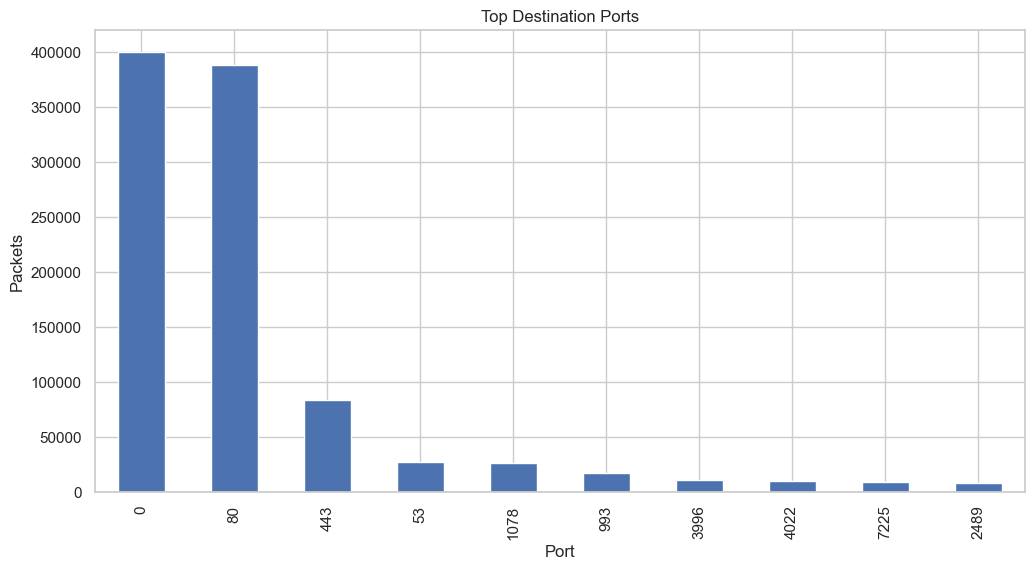

In [156]:
df_clean['dst_port'].value_counts().head(10).plot(kind='bar')
plt.title("Top Destination Ports")
plt.xlabel("Port")
plt.ylabel("Packets")
plt.show()


In [157]:
def ip_type(ip):
    try:
        ip_obj = ipaddress.ip_address(ip)
        if ip_obj.is_private:
            return "Private"
        else:
            return "Public"
    except:
        return "Invalid"

df_clean['Source IP Type'] = df_clean['src_ip'].apply(ip_type)

C:\Users\aminm\AppData\Local\Temp\ipykernel_13872\2725409512.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Source IP Type'] = df_clean['src_ip'].apply(ip_type)


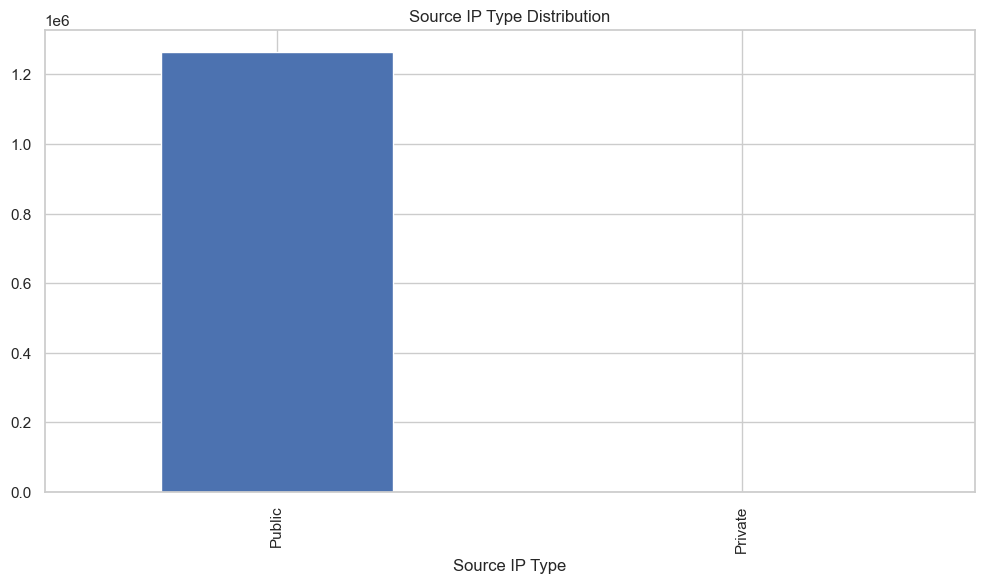

In [158]:
df_clean['Source IP Type'].value_counts().plot(kind='bar')
plt.title("Source IP Type Distribution")
plt.show()

In [159]:
df_clean = df.rename(columns={
    'srs_ip': 'Source IP',
    'srs_port': 'Source Port',
    'dst_ip': 'Destination IP',
    'dst_port': 'Destination Port',
    'protocol': 'Protocol',
    'packet_len': 'Packet Size (Bytes)'
})

In [160]:
df_clean.to_csv("traffic_clean1.csv", index=False)

In [161]:
df1= pd.read_csv("traffic_clean1.csv")
df1.head()

,src_ip,Destination IP,src_port,Destination Port,Protocol,Packet Size (Bytes),datetime
0,147.32.84.202,65.54.89.106,1078,80,TCP,54,2011-08-18 13:39:35.087798119
1,88.100.184.137,147.32.85.26,13121,62860,TCP,54,2011-08-18 13:39:35.087914944
2,147.32.85.26,88.100.184.137,62860,13121,TCP,54,2011-08-18 13:39:35.088321924
3,147.32.85.26,88.100.184.137,62860,13121,TCP,54,2011-08-18 13:39:35.088373899
4,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.089900970


In [162]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4060716 entries, 0 to 4060715
Data columns (total 7 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   src_ip               object
 1   Destination IP       object
 2   src_port             int64 
 3   Destination Port     int64 
 4   Protocol             object
 5   Packet Size (Bytes)  int64 
 6   datetime             object
dtypes: int64(3), object(4)
memory usage: 216.9+ MB


In [163]:
df1['datetime'] = pd.to_datetime(df1['datetime'], errors='coerce')

In [164]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4060716 entries, 0 to 4060715
Data columns (total 7 columns):
 #   Column               Dtype         
---  ------               -----         
 0   src_ip               object        
 1   Destination IP       object        
 2   src_port             int64         
 3   Destination Port     int64         
 4   Protocol             object        
 5   Packet Size (Bytes)  int64         
 6   datetime             datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 216.9+ MB


In [165]:
df1 = df1.rename(columns={
    'src_ip': 'Source IP',
    'src_port': 'Source Port'
})

In [166]:
df1.columns

Index(['Source IP', 'Destination IP', 'Source Port', 'Destination Port',
       'Protocol', 'Packet Size (Bytes)', 'datetime'],
      dtype='object')

In [167]:
df1['date'] = df1['datetime'].dt.date
df1['hour'] = df1['datetime'].dt.hour

In [168]:
df1['Protocol'] = df1['Protocol'].astype('category')

In [169]:
df1['Source Port'] = df1['Source Port'].astype('int16')
df1['Destination Port'] = df1['Destination Port'].astype('int16')

In [170]:
df1.to_csv("traffic_powerbi_ready.csv", index=False)

In [171]:
dfd= pd.read_csv("traffic_powerbi_ready.csv")
dfd.head()

,Source IP,Destination IP,Source Port,Destination Port,Protocol,Packet Size (Bytes),datetime,date,hour
0,147.32.84.202,65.54.89.106,1078,80,TCP,54,2011-08-18 13:39:35.087798119,2011-08-18,13
1,88.100.184.137,147.32.85.26,13121,-2676,TCP,54,2011-08-18 13:39:35.087914944,2011-08-18,13
2,147.32.85.26,88.100.184.137,-2676,13121,TCP,54,2011-08-18 13:39:35.088321924,2011-08-18,13
3,147.32.85.26,88.100.184.137,-2676,13121,TCP,54,2011-08-18 13:39:35.088373899,2011-08-18,13
4,65.54.89.106,147.32.84.202,80,1078,TCP,54,2011-08-18 13:39:35.089900970,2011-08-18,13


In [172]:
dfd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4060716 entries, 0 to 4060715
Data columns (total 9 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   Source IP            object
 1   Destination IP       object
 2   Source Port          int64 
 3   Destination Port     int64 
 4   Protocol             object
 5   Packet Size (Bytes)  int64 
 6   datetime             object
 7   date                 object
 8   hour                 int64 
dtypes: int64(4), object(5)
memory usage: 278.8+ MB


In [173]:
dfd['datetime'] = pd.to_datetime(dfd['datetime'], format='mixed', errors='coerce')

In [174]:
dfd['datetime'].dtype

dtype('<M8[ns]')

In [175]:
dfd['date'] = dfd['datetime'].dt.date

In [176]:
dfd['Protocol'] = dfd['Protocol'].astype('category')

In [177]:
dfd['Source Port'] = dfd['Source Port'].astype('int16')
dfd['Destination Port'] = dfd['Destination Port'].astype('int16')

In [178]:
dfd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4060716 entries, 0 to 4060715
Data columns (total 9 columns):
 #   Column               Dtype         
---  ------               -----         
 0   Source IP            object        
 1   Destination IP       object        
 2   Source Port          int16         
 3   Destination Port     int16         
 4   Protocol             category      
 5   Packet Size (Bytes)  int64         
 6   datetime             datetime64[ns]
 7   date                 object        
 8   hour                 int64         
dtypes: category(1), datetime64[ns](1), int16(2), int64(2), object(3)
memory usage: 205.2+ MB


In [179]:
dfd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4060716 entries, 0 to 4060715
Data columns (total 9 columns):
 #   Column               Dtype         
---  ------               -----         
 0   Source IP            object        
 1   Destination IP       object        
 2   Source Port          int16         
 3   Destination Port     int16         
 4   Protocol             category      
 5   Packet Size (Bytes)  int64         
 6   datetime             datetime64[ns]
 7   date                 object        
 8   hour                 int64         
dtypes: category(1), datetime64[ns](1), int16(2), int64(2), object(3)
memory usage: 205.2+ MB


In [180]:
dfd.head

<bound method NDFrame.head of               Source IP  Destination IP  Source Port  Destination Port  \
0         147.32.84.202    65.54.89.106         1078                80   
1        88.100.184.137    147.32.85.26        13121             -2676   
2          147.32.85.26  88.100.184.137        -2676             13121   
3          147.32.85.26  88.100.184.137        -2676             13121   
4          65.54.89.106   147.32.84.202           80              1078   
...                 ...             ...          ...               ...   
4060711   147.32.84.165    147.32.96.69            0                 0   
4060712   147.32.84.191    147.32.96.69            0                 0   
4060713   147.32.84.165    147.32.96.69            0                 0   
4060714   147.32.84.191    147.32.96.69            0                 0   
4060715   147.32.84.165    147.32.96.69            0                 0   

        Protocol  Packet Size (Bytes)                      datetime  \
0         

In [181]:
print("Loading data...")
df = pd.read_csv('traffic_powerbi_ready.csv')
print("Calculating Risk Metrics...")
risk_df = df.groupby('Source IP').agg(
    Total_Bytes=('Packet Size (Bytes)', 'sum'),          
    Total_Packets=('Source IP', 'count'),               
    Unique_Ports=('Destination Port', 'nunique')
).reset_index()
risk_df = risk_df.sort_values(by='Unique_Ports', ascending=False)
risk_df.to_csv('risk_analysis.csv', index=False)
print("Calculating Victim Metrics...")
victim_df = df.groupby('Destination IP').agg(
    Total_In_Bytes=('Packet Size (Bytes)', 'sum'),
    Attackers_Count=('Source IP', 'nunique'),              
    Target_Ports=('Destination Port', 'nunique')
).reset_index()
victim_df = victim_df.sort_values(by='Attackers_Count', ascending=False)
victim_df.to_csv('victim_analysis.csv', index=False)
print("Calculating Protocol Metrics...")
proto_df = df.groupby(['Protocol', 'Destination Port']).agg(
    Total_Bytes=('Packet Size (Bytes)', 'sum'),
    Total_Packets=('Protocol', 'count'),                 
    Avg_Packet_Size=('Packet Size (Bytes)', 'mean')        
).reset_index()
proto_df['Avg_Packet_Size'] = proto_df['Total_Bytes'] / proto_df['Total_Packets']
proto_df.to_csv('protocol_risk.csv', index=False)
print("All files generated successfully!")
print("Check 'risk_analysis.csv' to see your Top Risky IPs.")

Loading data...
Calculating Risk Metrics...
Calculating Victim Metrics...
Calculating Protocol Metrics...
All files generated successfully!
Check 'risk_analysis.csv' to see your Top Risky IPs.
